# SOLUTIONS

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)

Generating Data

In [2]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [6]:
def cal_cost(y_pred, X, y):
    '''
    Calculates the cost for given X and Y.
    y_pred = Vector of y_preds
    X = Row of X's np.zeros((2, j))
    y = Actual y's np.zeros((2, 1))

    where:
        j is the no of features
    '''

    m = len(y)

    predictions = X.dot(y_pred)
    cost = (1 / 2 * m) * np.sum(np.square(predictions - y))

    return cost

Change batch size in mini-batch gradient descent: Try a small size (e.g., 2) and a large size (e.g., 80). How does the loss curve change? What happens when the batch size equals the total number of samples?

In [7]:
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    '''
    X = Matrix of X without added bias units
    y = Vector of Y
    y_pred = Vector of y_preds np.random.randn(j, 1)
    learning_rate
    iterations = no of iterations

    Returns the final theta vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

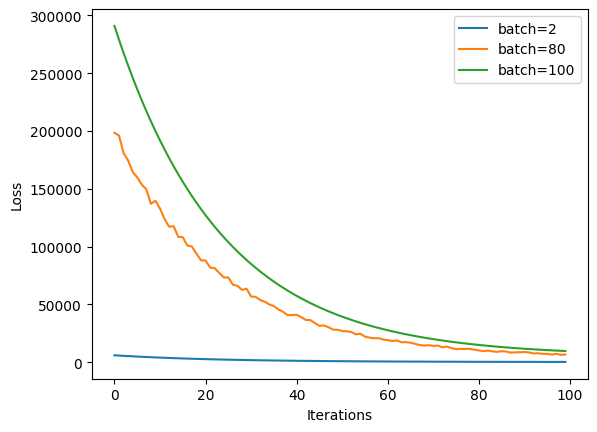

In [9]:
plt.plot(cost2, label="batch=2")
plt.plot(cost80, label="batch=80")
plt.plot(cost100, label="batch=100")
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

The loss curve changes significantly with different batch sizes. When the batch size is 2, the loss curve is irregular and fluctuates because the model updates weights very frequently using very small samples, causing noisy gradient estimates. With batch size 80, the loss curve becomes smoother since gradients are calculated using more samples, leading to more stable updates. When the batch size is 100 (equal to the total number of samples), the algorithm behaves like Batch Gradient Descent, producing the smoothest and most stable loss curve with the least fluctuation.

In [8]:
theta = np.random.randn(2,1)

theta2, cost2 = minibatch_gradient_descent(X, y, theta.copy(), batch_size=2, iterations=100)

theta80, cost80 = minibatch_gradient_descent(X, y, theta.copy(), batch_size=80, iterations=100)

theta100, cost100 = minibatch_gradient_descent(X, y, theta.copy(), batch_size=100, iterations=100)

Test on real datasets: Use a dataset from sklearn.datasets, like the Boston Housing or Diabetes datasets, and see how each variant performs.

In [31]:
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt

data = load_diabetes()

X = data.data
# Add a bias term (column of ones) to X
X = np.c_[np.ones(len(X)), X]
y = data.target.reshape(-1,1)

print(X.shape)

(442, 11)


In [11]:
theta = np.random.randn(X.shape[1],1)

In [12]:
def cal_cost(theta, X, y):
    m = len(y)
    predictions = np.dot(X, theta)
    cost = (1/(2*m)) * np.sum((predictions-y)**2)
    return cost

In [18]:
# def batch_gradient_descent(X, y, theta, lr=0.01, iterations=100):

#     m = len(y)
#     cost_history = np.zeros(iterations)

#     for i in range(iterations):

#         prediction = np.dot(X, theta)

#         theta = theta - (lr/m) * X.T.dot(prediction-y)

#         cost_history[i] = cal_cost(theta,X,y)

#     return theta, cost_history

In [14]:
# def stochastic_gradient_descent(X,y,theta,lr=0.01,iterations=100):

#     m = len(y)
#     cost_history = np.zeros(iterations)

#     for it in range(iterations):

#         for i in range(m):

#             rand = np.random.randint(m)

#             X_i = X[rand:rand+1]
#             y_i = y[rand:rand+1]

#             prediction = np.dot(X_i,theta)

#             theta = theta - lr * X_i.T.dot(prediction-y_i)

#         cost_history[it] = cal_cost(theta,X,y)

#     return theta,cost_history

In [15]:
# def minibatch_gradient_descent(X,y,theta,lr=0.01,iterations=100,batch_size=32):

#     m = len(y)
#     cost_history = np.zeros(iterations)

#     for it in range(iterations):

#         indices = np.random.permutation(m)

#         X_shuffled = X[indices]
#         y_shuffled = y[indices]

#         for i in range(0,m,batch_size):

#             X_i = X_shuffled[i:i+batch_size]
#             y_i = y_shuffled[i:i+batch_size]

#             prediction = np.dot(X_i,theta)

#             batch_m = len(X_i)

#             theta = theta - (lr/batch_m) * X_i.T.dot(prediction-y_i)

#         cost_history[it] = cal_cost(theta,X,y)

#     return theta,cost_history

In [16]:
# theta = np.random.randn(X.shape[1],1)

# theta_bgd, cost_bgd = batch_gradient_descent(X,y,theta.copy())

# theta_sgd, cost_sgd = stochastic_gradient_descent(X,y,theta.copy())

# theta_mbgd, cost_mbgd = minibatch_gradient_descent(X,y,theta.copy(),batch_size=32)

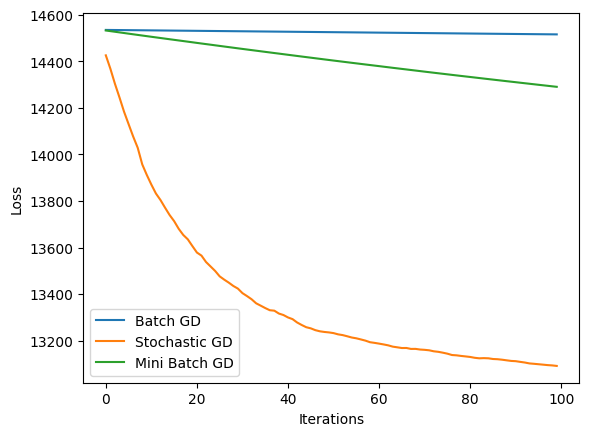

In [17]:
# plt.plot(cost_bgd,label="Batch GD")
# plt.plot(cost_sgd,label="Stochastic GD")
# plt.plot(cost_mbgd,label="Mini Batch GD")

# plt.xlabel("Iterations")
# plt.ylabel("Loss")
# plt.legend()
# plt.show()

atch Gradient Descent provides accurate and stable convergence but is slower for large datasets. Stochastic Gradient Descent converges faster but produces noisy updates because it uses only one sample at a time. Mini-Batch Gradient Descent combines the advantages of both methods by providing faster learning with better stability, making it the most widely used optimization technique in modern machine learning.

In [24]:
def batch_gradient_descent(X, y, theta, lr=0.0001, iterations=100):

    m = len(y)
    cost_history = np.zeros(iterations)

    for i in range(iterations):

        prediction = np.dot(X, theta)

        theta = theta - (lr/m) * X.T.dot(prediction-y)

        cost_history[i] = cal_cost(theta,X,y)

    return theta, cost_history
    #low learning rate

In [25]:
def stochastic_gradient_descent(X,y,theta,lr=0.01,iterations=100):

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):

        for i in range(m):

            rand = np.random.randint(m)

            X_i = X[rand:rand+1]
            y_i = y[rand:rand+1]

            prediction = np.dot(X_i,theta)

            theta = theta - lr * X_i.T.dot(prediction-y_i)

        cost_history[it] = cal_cost(theta,X,y)

    return theta,cost_history
    #normal learning rate

In [37]:
def sgd_with_schedule(X, y, theta, initial_lr=0.01, iterations=100):

    m = len(y)
    cost_history = np.zeros(iterations)

    for epoch in range(iterations):

        lr = initial_lr / (epoch + 1)

        for i in range(m):

            rand = np.random.randint(m)

            X_i = X[rand:rand+1]
            y_i = y[rand:rand+1]

            prediction = np.dot(X_i, theta)

            theta = theta - lr * X_i.T.dot(prediction - y_i)

        cost_history[epoch] = cal_cost(theta, X, y)

    return theta, cost_history
    #decreasing epochs

In [39]:
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.1, iterations=10, batch_size=20):
    '''
    X = Matrix of X (with bias unit included)
    y = Vector of Y
    y_pred = Vector of y_preds np.random.randn(j, 1) where j is num_features + 1
    learning_rate
    iterations = no of iterations

    Returns the final theta vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            X_i = X_shuffled[i: i + batch_size]
            y_i = y_shuffled[i: i + batch_size]

            # Bias term is now added to X globally before calling this function
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history
    #high learning rate

In [40]:
theta = np.random.randn(X.shape[1],1) # Re-initializing theta to match X's shape

theta_bgd, cost_bgd = batch_gradient_descent(X,y,theta.copy())

theta_sgd, cost_sgd = stochastic_gradient_descent(X,y,theta.copy())

theta_mbgd, cost_mbgd = minibatch_gradient_descent(X,y,theta.copy(),batch_size=32)
# Trigger re-execution

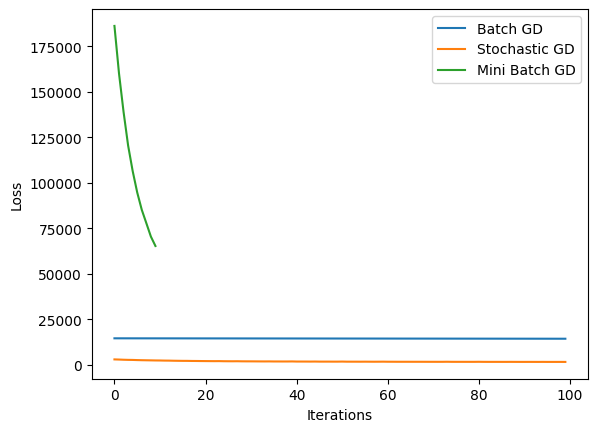

In [41]:
plt.plot(cost_bgd,label="Batch GD")
plt.plot(cost_sgd,label="Stochastic GD")
plt.plot(cost_mbgd,label="Mini Batch GD")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

The experiment shows that learning rate strongly affects optimization performance. A very low learning rate causes slow learning, while a very high learning rate can prevent convergence. Among all variants, SGD is the most sensitive to learning rate because of frequent noisy updates, whereas Batch GD is the most stable. Mini-Batch GD provides the best trade-off between speed and stability.

Using a decreasing learning rate schedule improves the performance of SGD. Compared to a fixed learning rate, the scheduled learning rate produces a smoother loss curve, reduces oscillations, and lowers the final error. This happens because large initial updates help the model learn quickly, while smaller updates later improve stability and allow better convergence near the minimum.